In [7]:
!pip install rapidfuzz

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rapidfuzz import process
import re
import seaborn as sns
from wordcloud import WordCloud
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("en_core_web_sm")

In [9]:
from google.colab import files
uploaded = files.upload()

Saving emails_dataset.json to emails_dataset (1).json
Saving emails_with_metadata.json to emails_with_metadata (1).json
Saving epstein-flights-2026-04-01.csv to epstein-flights-2026-04-01 (1).csv


# Contextualização

* Arquivos relacionados a Jeffrey Epstein, financista acusado de tráfico sexual de menores
* Investigado por manter uma rede de exploração envolvendo pessoas influentes
* Preso em 2019 e encontrado morto enquanto aguardava julgamento
* Documentos incluem: e-mails, fotos, contatos, registros judiciais, histórico de viagens e depoimentos
* Parte do material veio de processos como o de Ghislaine Maxwell, sua associada


* Os dados foram retirados das divulgações Volume 9-12 do Departamento de Justiça Americano. Fizemos análises com base nos e-mails e no histórico de viagens presentes nos arquivos.
* Contamos com 3652 viagens e 2322 e-mails
* 4509 pessoas citadas
* 328 lugares diferentes visitados
* 326 crimes cometidos

* **Problemática**: quantidade de documentos impossível de ser analisada por completo.

Limitamos a primeira análise somente a **e-mails** e **registros de vôos** devido à grande quantidade de documentos disponíveis.
Novos documentos podem ser adicionados na medida que nossas análises apontem certas observações que possam ser comprovadas com outras evidências, ou que seja possível selecionar áreas específicas de estudo.

# Estrutura dos dados

### setup

In [10]:
flights = pd.read_csv('epstein-flights-2026-04-01.csv')
flights = flights.rename(columns={'Date': 'date', 'Origin': 'origin', 'Destination': 'destination', 'Aircraft': 'aircraft', 'Passengers': 'passengers', 'Pilot': 'pilot', 'Notes': 'notes'})
flights = flights.sort_values(by='date', ascending=True).reset_index(drop=True)
flights['date'] = pd.to_datetime(flights['date'])

In [11]:
emails = pd.read_json('emails_with_metadata.json')
emails = emails.sort_values(by='date', ascending=True).reset_index(drop=True)

In [12]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z]+', ' ', text)

    doc = nlp(text)
    processed_tokens = []

    for token in doc:
        if not token.is_stop and not token.is_punct and len(token.text) > 2:
            processed_tokens.append(token.lemma_)

    return " ".join(processed_tokens)

In [13]:
def last_match(text):
    last_pos = 0
    for match in re.finditer(r'((wrote:)|(To:)|(Subject:)|(Importance:)|(Sent:(.|\n)*?(AM|PM))).*?\n', text):
        last_pos = match.end()
    return text[last_pos:]

In [14]:
emails['email_text'] = emails['email_text'].apply(last_match).str.replace('\n', ' ')

##

* Textos extraídos dos registros de passageiros dos vôos particulares de Epstein.
* Contém informações de origem e partida, passageiros e comentários
* Alguns nomes estão censurados

In [15]:
flights.head(5).style.hide()

date,origin,destination,aircraft,passengers,pilot,notes
1991-04-25 00:00:00,"Palm Springs International, CA","John Glenn Columbus International, OH",N125JE (Hawker HS-125),Mr. Martino,nan,NESTLE MR. MARIENO
1991-04-30 00:00:00,"John Glenn Columbus International, OH","Palm Springs International, CA",N125JE (Hawker HS-125),Del Coleman,nan,DEL COLEMAN
1991-05-01 00:00:00,"Palm Springs International, CA","John Glenn Columbus International, OH",N125JE (Hawker HS-125),Del Coleman,nan,DEL COLEMAN
1991-05-02 00:00:00,"John Glenn Columbus International, OH","John Glenn Columbus International, OH",N125JE (Hawker HS-125),Saul Levy,nan,SAUL LEVY
1991-05-06 00:00:00,"John Glenn Columbus International, OH",CPS Airport,N125JE (Hawker HS-125),nan,nan,"TO MAINJON (illegible), BELOW THE FLOOR TRAYS, 20 YEAR. XDDYS, FOXGER BOND, GONE HATCH..."


In [16]:
emails.head(1).style.format({
    'email_text':
        lambda x: f"{x[:300]}..." if len(x) > 300 else x,
    'summary':
        lambda x: f"{x[:300]}..." if len(x) > 300 else x,
    'key_quotes':
        lambda x: f"{x[:300]}..." if len(x) > 300 else x}
    ).hide().set_properties(**{
    'white-space': 'normal',
    'text-align': 'left',
    'max-width': '600px',
})

document_id,email_text,source_file,is_email,participants,date,time,subject,has_attachments,attachment_names,people_mentioned,organizations,locations,phone_numbers,urls,notable_figures,primary_topic,topics,inferred_people,summary,key_quotes,tone,potential_crimes,evidence_strength,crime_types,mentions_victims,victim_names,cover_up
HOUSE_OVERSIGHT_016595,"Kirk: We had our June monthly ARCOM meeting yesterday. You likely know that ARCOM is working with Mr. Trump to re-install a hedge on his North County Road property. I believe this case is now pending in front of Code Enforcement. In May, ARCOM approved a plan to replace the former hedge with silver ...",TEXT/001/HOUSE_OVERSIGHT_016595.txt,True,"[{'name': 'Kirk Blouin', 'email': ''}, {'name': 'John Page', 'email': ''}, {'name': 'Tim Frank', 'email': ''}, {'name': 'Ray Royce', 'email': ''}, {'name': 'Rob Walton', 'email': ''}, {'name': 'Sgt. Krauel', 'email': ''}, {'name': 'Mr. Randolph', 'email': ''}, {'name': 'Mr. Fried', 'email': ''}, {'name': 'Ms. Van Buren', 'email': ''}]",2008-06-26 00:00:00,14:09:06,Re: ARCOM,False,[],"['Kirk Blouin', 'John Page', 'Rob Walton', 'Abe Gosman', 'Ray Royce', 'Mr. Randolph', 'Tim Frank', 'Mr. Trump', 'Mr. Fried', 'Ms. Van Buren', 'Sgt. Krauel']","['Trump Properties LLC', 'Town of Palm Beach', 'Architectural Commission', 'Code Enforcement Board', 'ARCOM']","['515 N. County Road', 'Palm Beach', 'North County Road']",[],[],['Donald Trump'],real_estate,"['real_estate', 'legal']",[],"The email conversation discusses a code enforcement case involving Trump Properties, LLC, regarding a violation of a Town of Palm Beach Code Ordinance about maintaining a hedge as per an Architectural Commission agreement. The participants detail the history of the case, actions taken by the Town, a...","['""We had our June monthly ARCOM meeting yesterday... ARCOM is working with Mr. Trump to re-install a hedge on his North County Road property.""', '""The Town does not feel this matter should be postponed.""', '""The recommendation would be that they are found in violation, assessed the $150.00 in administrative costs and be given until June 18th to comply.""', '""ARCOM said NO and directed the attorney and landscaper to get the trees in ASAP.""', '""Their patience is wearing thin with the whole hedge issue...""']",routine,,none,[],False,[],


# Análise exploratória

* Estudo inicial procurando relações entre as duas bases de dados
* Seleção de padrões textuais interessantes que podem ser aprofundados

## Volume ao longo do tempo

<Axes: xlabel='date'>

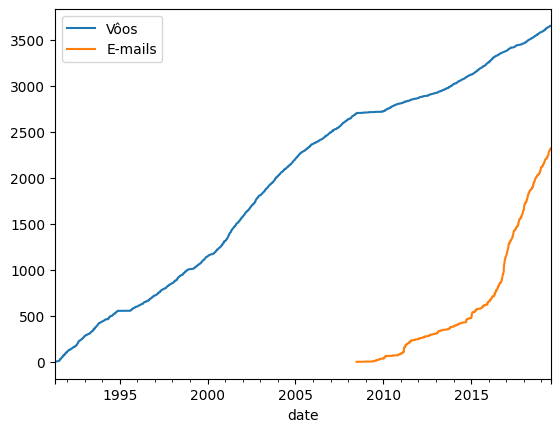

In [17]:
flights.groupby(['date'])[['origin']].count().cumsum().resample('D').ffill().rename(columns={'origin':'Vôos'}).join(
    emails.groupby(['date'])[['email_text']].count().cumsum().resample('D').ffill().rename(columns={'email_text':'E-mails'}),
    how='outer'
).plot()

<Axes: xlabel='date'>

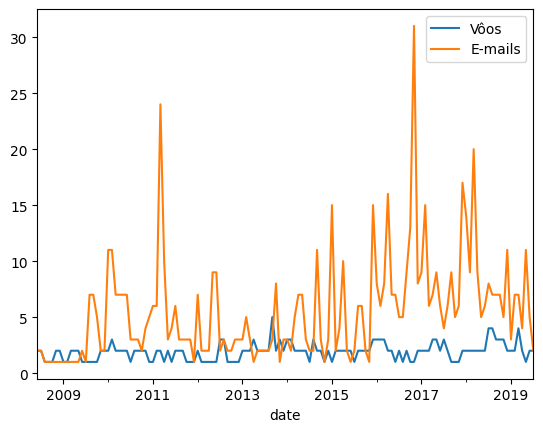

In [18]:
dt = flights.groupby(['date'])[['origin']].count().resample('D').ffill().join(emails.groupby(['date'])[['email_text']].count().resample('D').ffill(), on='date')
dt.to_period('M').groupby(['date']).max()[emails['date'].min():].rename(columns={'email_text':'E-mails', 'origin':'Vôos'}).plot()

##Volume por tom ao longo do tempo

In [37]:
# Instale se necessário: !pip install textblob
from textblob import TextBlob

def get_sentiment(text):
    if not text or pd.isna(text):
        return 0
    # A TextBlob analisa o sentimento do texto em inglês
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

# Criando a coluna de sentimento (pode demorar alguns segundos)
emails['sentiment'] = emails['email_text'].apply(get_sentiment)

# Visualizando os e-mails mais "pesados" ou "negativos"
print("E-mails com sentimentos mais negativos:")
display(emails[['date', 'sentiment', 'email_text']].sort_values(by='sentiment').head(5))

E-mails com sentimentos mais negativos:


,date,sentiment,email_text
1997,2018-08-29,-0.937500,In Europe saw this it will drive him crazy!! ...
1211,2017-01-29,-0.900000,Malevolence Tempered by Incompetence: Trump's ...
1451,2017-07-21,-0.800000,Trump is truly stupid. HOUSE OVERSIGHT 032552
1404,2017-05-30,-0.700000,Bad news for TJB https://urldefense.proofpoin...
816,2016-07-15,-0.416667,"Jeffrey Epstein uaily upaate • July i, 2016 ..."


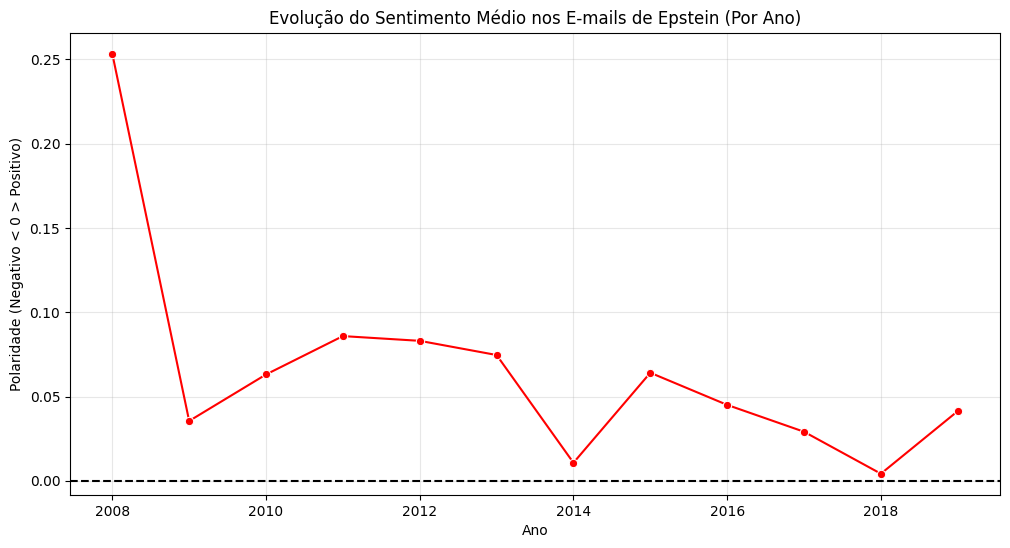

In [38]:


# Garantindo que a data está no formato correto
emails['date'] = pd.to_datetime(emails['date'])
emails['year'] = emails['date'].dt.year

# Agrupando a média de sentimento por ano
sentiment_yearly = emails.groupby('year')['sentiment'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sentiment_yearly, x='year', y='sentiment', marker='o', color='red')
plt.axhline(0, color='black', linestyle='--') # Linha neutra
plt.title('Evolução do Sentimento Médio nos E-mails de Epstein (Por Ano)')
plt.ylabel('Polaridade (Negativo < 0 > Positivo)')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)
plt.show()

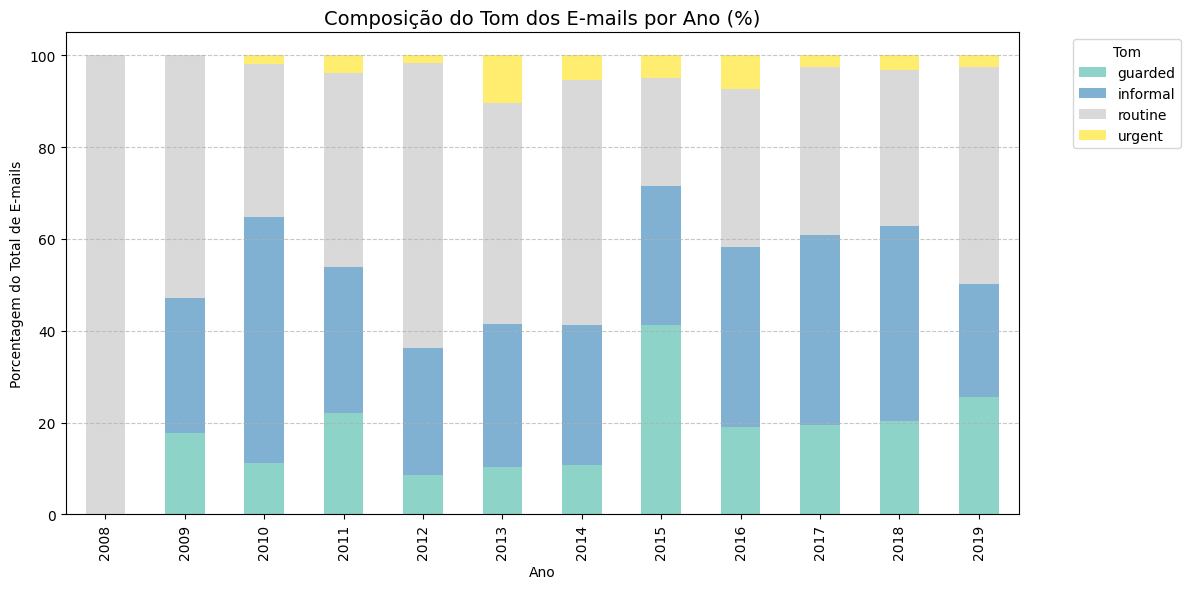

In [39]:
# Preparação dos dados
emails['year'] = pd.to_datetime(emails['date']).dt.year

# Criar uma tabela cruzada de Ano vs Tom
tone_year_dist = pd.crosstab(emails['year'], emails['tone'])

# Converter para porcentagem (100% stacked bar) para ver a mudança na composição
tone_year_pct = tone_year_dist.div(tone_year_dist.sum(1), axis=0) * 100

# Plotagem
ax = tone_year_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')

plt.title('Composição do Tom dos E-mails por Ano (%)', fontsize=14)
plt.ylabel('Porcentagem do Total de E-mails')
plt.xlabel('Ano')
plt.legend(title='Tom', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [40]:
# Gerando a tabela de resumo para o seu slide
tone_summary = emails.groupby(['year', 'tone']).size().unstack(fill_value=0)

print("--- DISTRIBUIÇÃO DE TOM POR ANO (VALORES ABSOLUTOS) ---")
print(tone_summary)

print("\n--- PERCENTUAL DE CADA TOM POR ANO ---")
tone_pct = tone_summary.div(tone_summary.sum(axis=1), axis=0) * 100
print(tone_pct.round(2).astype(str) + '%')

--- DISTRIBUIÇÃO DE TOM POR ANO (VALORES ABSOLUTOS) ---
tone  guarded  informal  routine  urgent
year                                    
2008        0         0        4       0
2009        6        10       18       0
2010        6        29       18       1
2011       35        50       67       6
2012        5        16       36       1
2013        8        24       37       8
2014       10        28       49       5
2015       74        54       42       9
2016       95       196      171      37
2017       97       207      183      13
2018       94       198      157      15
2019       52        50       96       5

--- PERCENTUAL DE CADA TOM POR ANO ---
tone guarded informal routine  urgent
year                                 
2008    0.0%     0.0%  100.0%    0.0%
2009  17.65%   29.41%  52.94%    0.0%
2010  11.11%    53.7%  33.33%   1.85%
2011  22.15%   31.65%  42.41%    3.8%
2012   8.62%   27.59%  62.07%   1.72%
2013  10.39%   31.17%  48.05%  10.39%
2014  10.87%   30.43%  53.

## Termos chave

#### setup

In [19]:
names = pd.concat([emails['people_mentioned'].explode(),
                   flights['passengers'].str.split(';').explode()]
                  ).unique()
people = pd.DataFrame(columns=['name', 'email_frequency', 'flight_frequency', 'first_email', 'first_flight'])
people['name'] = names

In [20]:
people['email_frequency'] = people['name'].apply(
     lambda x:
          emails['people_mentioned']
          .apply(lambda y: x in y)
          .sum())

people['flight_frequency'] = people['name'].apply(
     lambda x:
          flights['passengers']
          .dropna()
          .str.split(';')
          .apply(
               lambda y:
                    x in y
               ).sum())

people['first_email'] = people['name'].apply(
     lambda x:
          emails
          .loc[emails['people_mentioned']
               .apply(lambda y: x in y)
          ].first_valid_index()
     ).apply(
          lambda x:
               emails.iloc[int(x)]['date']
               if not np.isnan(x)
               else np.nan)

people['first_flight'] = people['name'].apply(
     lambda x:
          flights[['passengers', 'date']].dropna()
     .loc[flights['passengers']
          .dropna()
          .str.split(';')
          .apply(lambda y: x in y)
          ].first_valid_index()
     ).apply(
         lambda x:
               flights.iloc[int(x)]['date']
                    if not np.isnan(x)
                    else np.nan)

In [21]:
name_map = {
    "trump": "donald trump",
    "jeff epstein": "jeffrey epstein",
    "jeffrey": "jeffrey epstein",
    "donald j. trump": "donald trump"
}

people["name"] = (
    people["name"]
    .str.lower()
    .str.strip()
    .replace(name_map)
)

### Frequência de termos chave

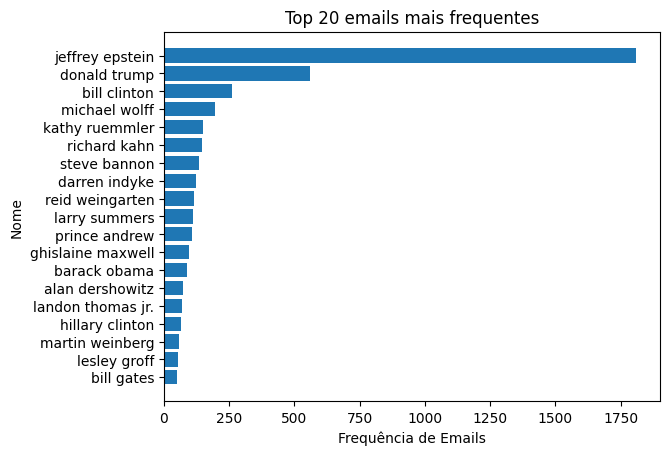

In [22]:
mentioned_names = (
    people[['name', 'email_frequency']]
    .sort_values(by='email_frequency', ascending=False)
    .reset_index(drop=True)
    .head(20)
)

plt.figure()
plt.barh(mentioned_names['name'], mentioned_names['email_frequency'])
plt.gca().invert_yaxis()

plt.xlabel("Frequência de Emails")
plt.ylabel("Nome")
plt.title("Top 20 emails mais frequentes")

plt.show()

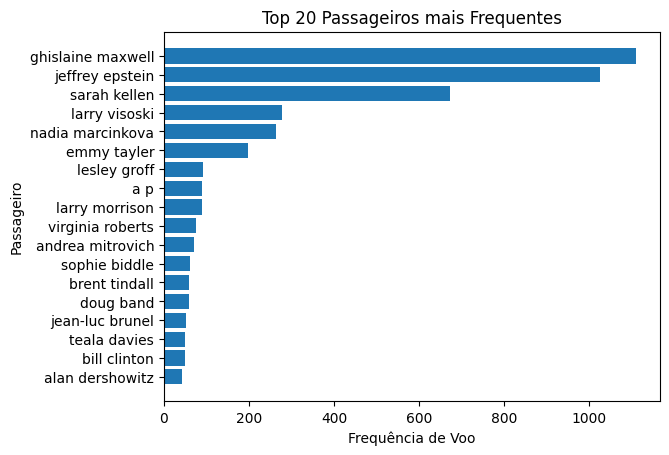

In [23]:
mentioned_names = (
    people[['name', 'flight_frequency']]
    .sort_values(by='flight_frequency', ascending=False)
    .reset_index(drop=True).head(20)
)

plt.figure()
plt.barh(mentioned_names['name'], mentioned_names['flight_frequency'])
plt.gca().invert_yaxis()

plt.xlabel("Frequência de Voo")
plt.ylabel("Passageiro")
plt.title("Top 20 Passageiros mais Frequentes")

plt.show()

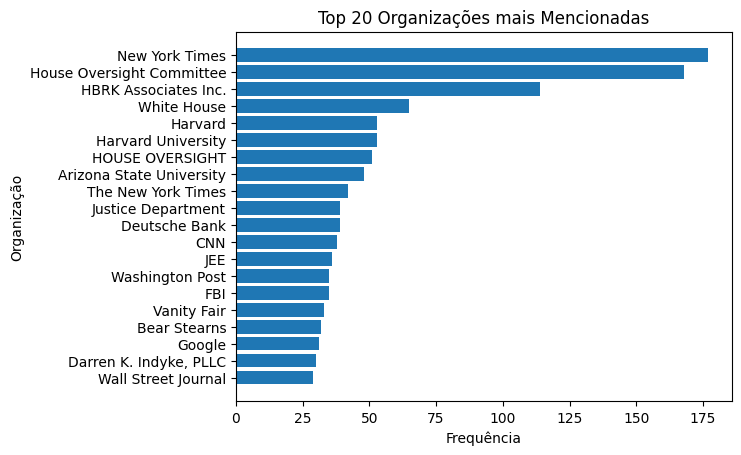

In [24]:
top_orgs = (
    emails["organizations"]
    .explode()
    .dropna()
    .value_counts()
    .head(20)
)

plt.figure()
plt.barh(top_orgs.index, top_orgs.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Organização")
plt.title("Top 20 Organizações mais Mencionadas")

plt.show()

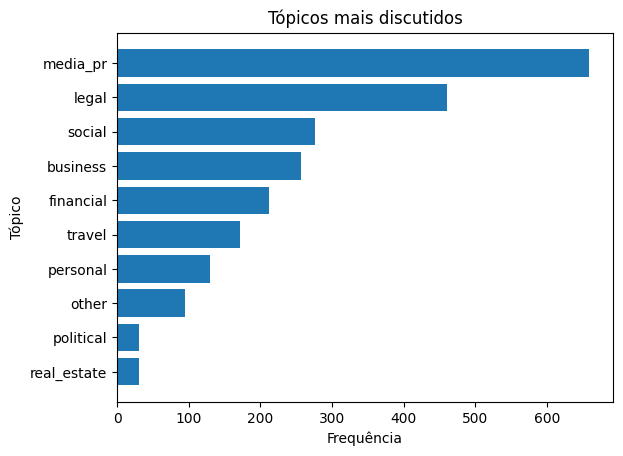

In [25]:
topics = (
    emails["primary_topic"]
    .explode()
    .dropna()
    .value_counts()
)

plt.figure()
plt.barh(topics.index, topics.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Tópico")
plt.title("Tópicos mais discutidos")

plt.show()

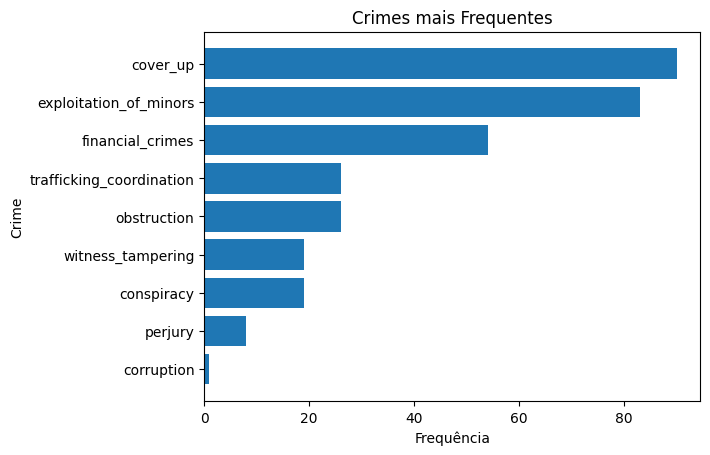

In [26]:
crimes = (
    emails["crime_types"]
    .explode()
    .dropna()
    .value_counts()
)

plt.figure()
plt.barh(crimes.index, crimes.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Crime")
plt.title("Crimes mais Frequentes")

plt.show()

#### Visualização

In [27]:
def generate_wordclouds(df, text='email_text', category_column=None):
    if category_column is None:
        texts = " ".join(df[text].dropna().apply(preprocess_text))

        wc = WordCloud(background_color="white", width=800, height=400).generate(texts)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title("General Wordcloud")
        plt.show()

    else:
        categories = df[category_column].unique()

        for category in categories:
            filtered_df = df[df[category_column] == category]
            texts = " ".join(filtered_df[text].dropna().apply(preprocess_text))

            if not texts.strip():
                continue

            wc = WordCloud(background_color="white", width=800, height=400).generate(texts)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis("off")
            plt.title(f"Wordcloud {category_column} - {category}")
            plt.show()

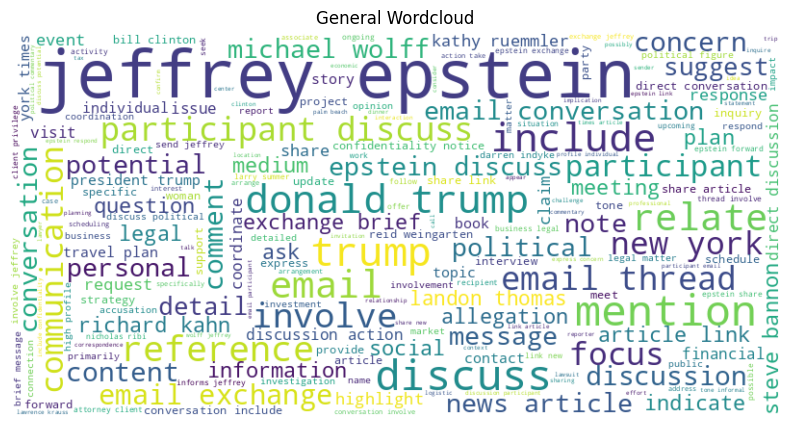

In [28]:
generate_wordclouds(emails, text='summary')

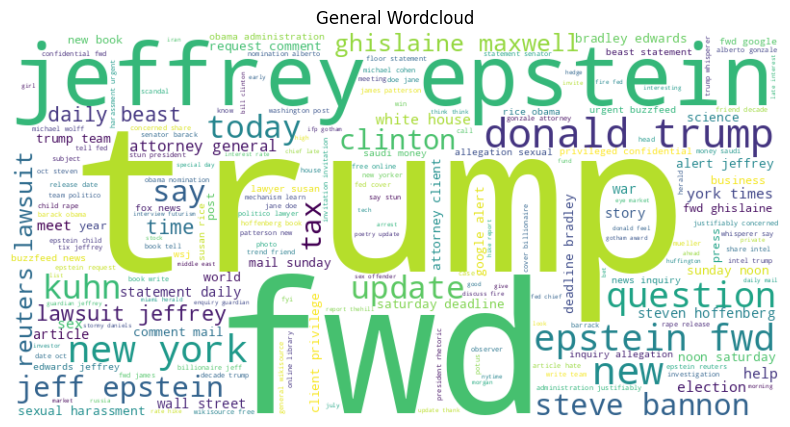

In [29]:
generate_wordclouds(emails, text='subject')

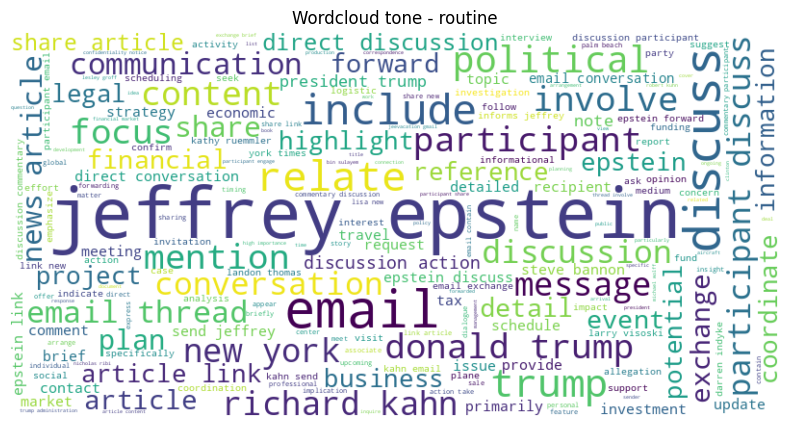

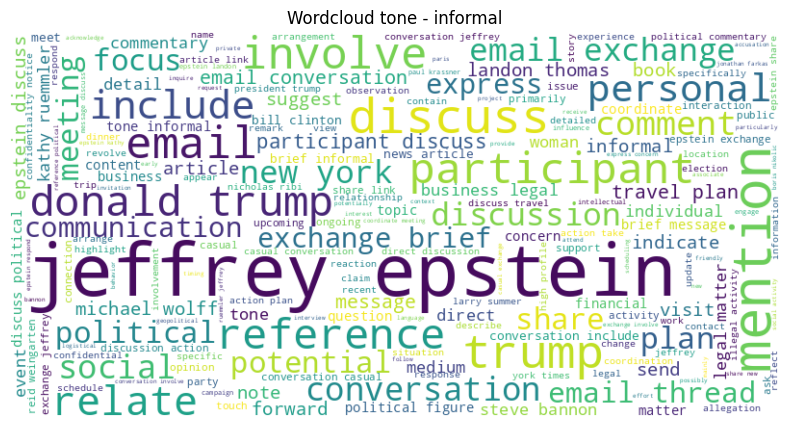

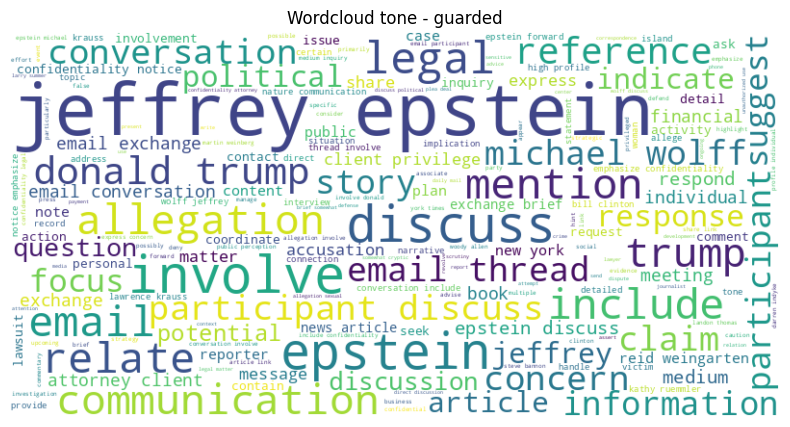

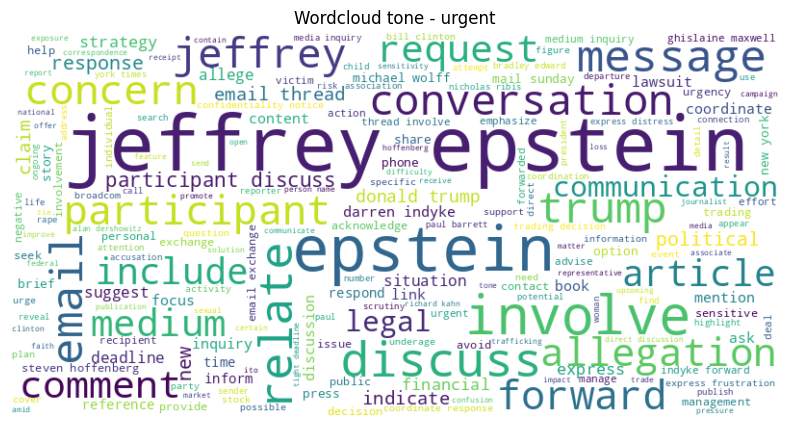

In [30]:
generate_wordclouds(emails, text='summary', category_column='tone')

In [31]:
generate_wordclouds(emails, text='summary', category_column='crime_types')

TypeError: unhashable type: 'list'

### Tipos de email

/tmp/ipykernel_29186/2514337999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


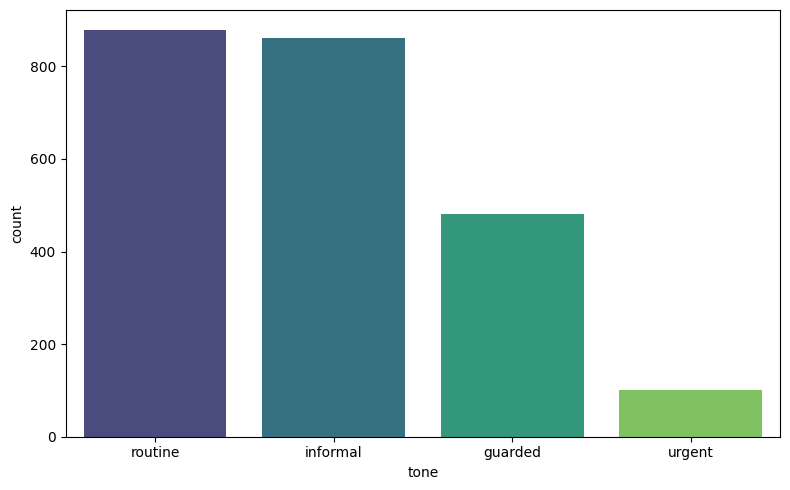

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.countplot(
    data=emails,
    x='tone',
    order=emails['tone'].value_counts().index,
    palette='viridis'
)

plt.tight_layout()

### TF-IDF (Importância de termos)

*Term Frequency-Inverse Document Frequency*

Métrica simples de importância de termos de acordo com sua frequência nos textos

#### setup

In [33]:
people.loc[(people['email_frequency'] > 0) & (people['flight_frequency'] > 0)]

,name,email_frequency,flight_frequency,first_email,first_flight
20,jeffrey epstein,1810,1005,2009-04-18,1991-07-26
37,bill clinton,260,14,2009-06-19,2002-02-09
65,ghislaine maxwell,96,42,2009-08-11,1992-01-05
102,bill gates,51,1,2009-10-31,2013-03-01
228,gerald lefcourt,10,2,2010-02-26,2006-12-21
245,alan dershowitz,73,3,2010-02-26,2004-02-05
810,jeffrey epstein,5,9,2011-04-26,1991-07-29
1951,larry visoski,44,278,2014-06-07,2001-08-30
3888,john roberts,1,2,2018-11-21,2010-03-22


In [34]:
vectorizer = TfidfVectorizer()
vector = vectorizer.fit_transform(emails['email_text'].apply(preprocess_text))

In [35]:
words = pd.DataFrame(columns=[1,2,3,4,5])

X_tfidf = vector.toarray()
vocab = vectorizer.vocabulary_

reverse_vocab = {v:k for k,v in vocab.items()}

feature_names = vectorizer.get_feature_names_out()

idx = X_tfidf.argsort(axis=1)
tfidf_max5 = idx[:,-5:]

words[[1,2,3,4,5]] = [[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]

#### Resultados

In [36]:
pd.DataFrame(pd.DataFrame([[[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]]).transpose().explode(0).value_counts()).rename_axis("").head(25).style.background_gradient()

,count
,
communication,958
thereof,550
mail,488
use,430
information,356
epstein,116
landon,104
thomas,94
timestopic,48
